In [8]:
from nba_api.stats.endpoints import leaguegamefinder
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.pyplot import Axes
import os
from PIL import Image
from pathlib import Path
import numpy as np

csv_dir = 'csvs'

# Pull data from the 2025-2026 NBA season
games_26 = leaguegamefinder.LeagueGameFinder(season_nullable='2025-26', season_type_nullable='Regular Season')
# get data frame from returned list
df_26: pd.DataFrame = games_26.get_data_frames()[0]
# Write data to csv for easier viewing. Not necessary
df_26.to_csv(os.path.join(csv_dir,'25_26_season_raw_data.csv') ,index=False)

In [9]:
# 2025-26
team_stats_26 = df_26[['SEASON_ID','TEAM_ABBREVIATION', 'PTS', 'WL']]
# Change Season ID Value
team_stats_26['SEASON_ID'] = '2025-26'
# Write to csv for easy viewing
team_stats_26.to_csv(os.path.join(csv_dir,'26_season_filtered_points.csv'), index=False)

In [10]:
# Aggregating Game data based off of the game ID
game_stats = df_26[['TEAM_ABBREVIATION', 'GAME_ID', 'MATCHUP' , 'WL', 'PTS' ]]
# New Names
name_dict = {
    'TEAM_ABBREVIATION': 'team',
    'GAME_ID': 'gameid',
    'MATCHUP': 'opp',
    'PTS': 'points',
}
game_stats = game_stats.rename(columns=name_dict)
game_stats['home/away'] = game_stats["opp"].apply(lambda x: "away" if "@" in x else "home")
game_stats['opp'] = game_stats['opp'].str[-3:]

def opp_score(x,y):

    score: int = game_stats['points'].loc[(game_stats['team']== x) & (game_stats['gameid']==y)].values[0]

    return score

game_stats['opp_score'] = game_stats.apply(lambda x: opp_score(x['opp'], x['gameid']), axis = 1)
print(game_stats.head())

  team      gameid  opp WL  points home/away  opp_score
0  GSW  0022501199  LAC  L     110      away        115
1  NYK  0022501190  CHA  L      96      home        110
2  PHI  0022501191  MIL  W     126      home        106
3  DAL  0022501193  CHI  W     149      home        128
4  DEN  0022501197  SAS  W     128      away        118


In [ ]:
# Repeating the same steps performed previously, but for the 2025-26 season.
overall_avg = (
    team_stats_26.groupby('TEAM_ABBREVIATION')
    .agg(
        points=('PTS', 'mean'),
    )
).reset_index()

overall_avg.to_csv(os.path.join(csv_dir,'overall_avg.csv'), index=False)

# Filter Data frame for just the wins of each team
wins_data = team_stats_26[team_stats_26['WL'] == 'W']
# wins_data.to_csv(os.path.join(csv_dir,'wins_raw.csv'), index=False)
# print(wins_data.head())

league_win_avg = sum(wins_data['PTS'])/len(wins_data['PTS'])

print(league_win_avg)
# Aggregate the Wins Data
wins_agg = (
    wins_data.groupby('TEAM_ABBREVIATION')
    .agg(
        points=('PTS', 'mean'),
        wins=('WL', lambda s: (s=='W').sum())
    )
).reset_index()
wins_agg = wins_agg.rename(columns={'TEAM_ABBREVIATION':'teams'})
print(wins_agg.head())
wins_agg.to_csv(os.path.join(csv_dir,'wins_avg.csv'), index=False)

  SEASON_ID TEAM_ABBREVIATION  PTS WL
2   2025-26               PHI  126  W
3   2025-26               DAL  149  W
4   2025-26               DEN  128  W
5   2025-26               MIA  143  W
6   2025-26               MIN  132  W
122.24471544715448
  teams      points  wins
0   ATL  123.521739    46
1   BKN  116.300000    20
2   BOS  120.446429    56
3   CHA  121.795455    44
4   CHI  125.000000    31


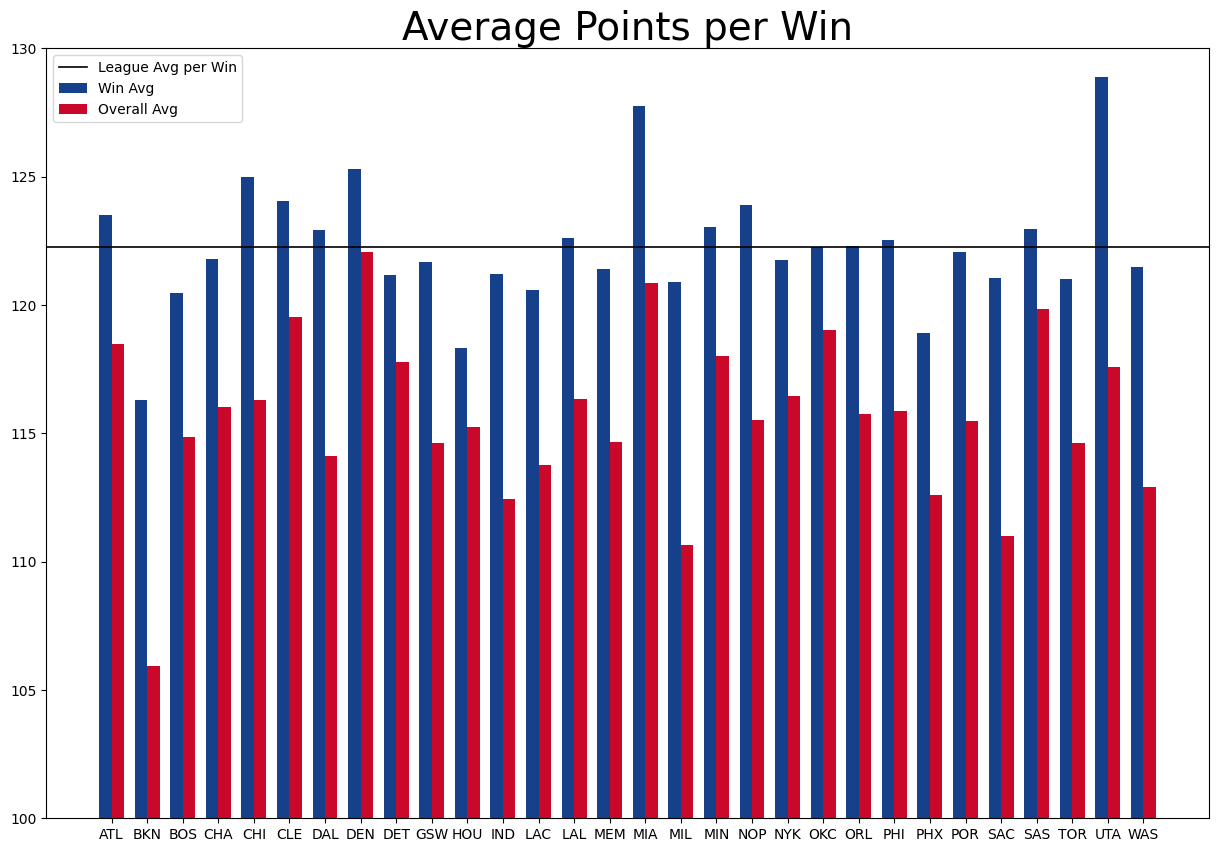

In [20]:
teams = list(overall_avg['TEAM_ABBREVIATION'])
x = np.arange(len(teams))  # Numerical locations for labels
width = 0.35  # Width of each bar

# create a figure and axis to plot a bar graph
fig, ax = plt.subplots(figsize =(15, 10))
# create and object for when plotting bar graph so that it can be looped through later. Bar graph consist of team and 'p_diff' and ronuded 2 places.
#bars_win = ax.bar(wins_agg['teams'], round(wins_agg['points'], 2), label = "Win Avg") # color = '#17408B'
#bars_ovr = ax.bar(overall_avg['TEAM_ABBREVIATION'], round(overall_avg['points'], 2), label = "Overall Avg")

bars_win = ax.bar(x - width/2, wins_agg['points'], width, label = "Win Avg", color='#17408B')
bars_ovr = ax.bar(x + width/2, overall_avg['points'], width, label = "Overall Avg", color='#C9082A')

# league_win_avg = sum(wins_agg['points'])/len(wins_agg['points'])

ax.set_ylim(100,130)
plt.title("Average Points per Win", fontsize = 28)
ax.set_xticks(x)
ax.set_xticklabels(teams)
plt.axhline(league_win_avg, color='black', linewidth=1.2, label = 'League Avg per Win') # Add a line at League Average points for wins for clarity
plt.legend()
plt.savefig('plots/points_per_win.png') # save figure off as a .png
plt.show()

    team      gameid  opp WL  points home/away  opp_score
35   UTA  0022501181  MEM  W     147      home        101
375  UTA  0022501014  MIL  W     128      home         96
535  UTA  0022500934  GSW  W     119      home        116
599  UTA  0022500900  WAS  W     122      away        112
844  UTA  0022500786  SAC  W     121      home         93


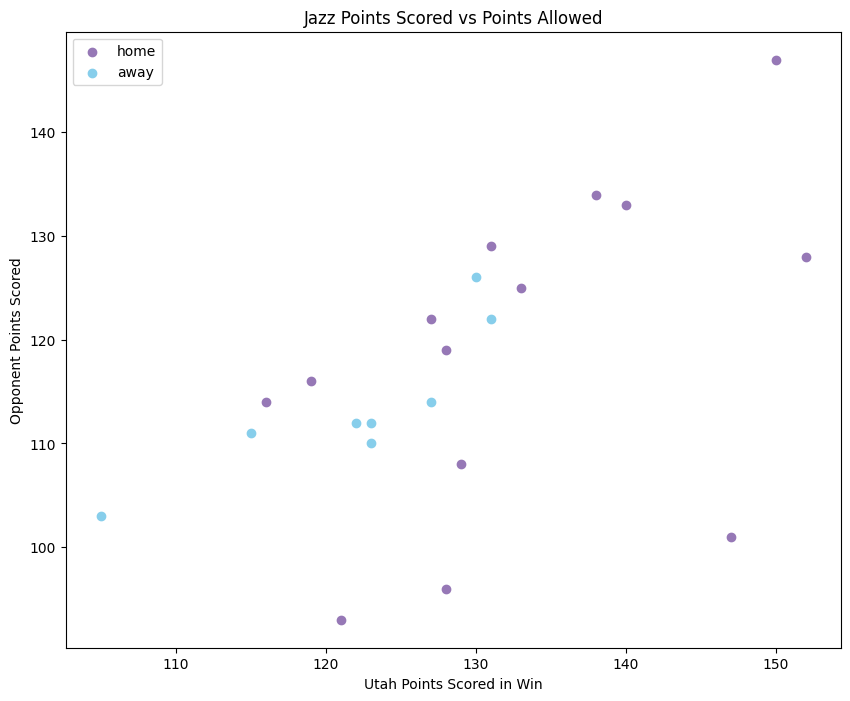

In [37]:
uta_wins = game_stats[(game_stats['team']== 'UTA') & (game_stats['WL'] == 'W')]
print(uta_wins.head())

mt_purp = '#9678b6'
sky_blue = '#87CEEB'
colors = [mt_purp if x == 'home' else sky_blue for x in uta_wins['home/away']]
uta_home = uta_wins[uta_wins['home/away'] == 'home']
uta_away = uta_wins[uta_wins['home/away'] == 'away']


fig2, ax2 = plt.subplots(figsize =(10, 8))
# plt.scatter(uta_wins['points'], uta_wins['opp_score'], color=colors)
scat_home = plt.scatter(uta_home['points'], uta_home['opp_score'], color=mt_purp)
scat_away = plt.scatter(uta_away['points'], uta_away['opp_score'], color=sky_blue)
plt.title('Jazz Points Scored vs Points Allowed')
ax2.set_xlabel("Utah Points Scored in Win")
ax2.set_ylabel("Opponent Points Scored")
plt.legend(['home', 'away'])
plt.show()